<a href="https://colab.research.google.com/github/alfredo-rios/ab_testing_landing_page/blob/main/ab_testing_landing_page.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [ ]:
# cargar archivo
df = pd.read_csv('/content/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:

# información general
df.info()
df.isna().sum()
for columna in ['landing','region','dispositivo',
                'traffic_source','user_type','converted']:
    print(columna)
    print(df[columna].value_counts())
    print()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB
landing
B    20018
A    19982
Name: landing, dtype: int64

region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo
Mobile     24829
Desktop    15171
Name

,converted,gasto
count,40000.00000,40000.000000
mean,0.14265,9.325554
std,0.34972,25.667986
min,0.00000,0.000000
25%,0.00000,0.000000
50%,0.00000,0.000000
75%,0.00000,0.000000
max,1.00000,303.680000


- El conjunto de datos contiene 40,000 registros y 9 variables. No se identificaron valores ausentes.
- La columna date se encontraba almacenada como tipo object, por lo que será convertida a datetime para facilitar su análisis temporal.
- Las variables categóricas presentan únicamente las categorías esperadas. La distribución entre las versiones de la landing page está prácticamente balanceada (19,982 usuarios en A y 20,018 en B), lo que favorece una comparación estadística confiable entre ambos grupos.
- De forma exploratoria, se observa que aproximadamente el 14.3% de los usuarios realizaron una conversión (5,706 de 40,000), mientras que la mayoría no convirtió y, por ello, la mediana y los cuartiles de la variable gasto son iguales a cero. Esto es consistente con la naturaleza del experimento, donde solo los usuarios que convierten generan un gasto.
- En general, el conjunto de datos presenta una calidad adecuada para continuar con el análisis del experimento A/B.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].duplicated().sum()

0

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
#Corregir tipo de dato
df['date'] = pd.to_datetime(df['date'])
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
categoricas = [
    'landing',
    'region',
    'dispositivo',
    'traffic_source',
    'user_type'
]

print("\nConteo de categorías:")

for col in categoricas:
    print(f"\n{col}")
    print(df[col].value_counts())


Conteo de categorías:

landing
B    20018
A    19982
Name: landing, dtype: int64

region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


- Se verificó que todos los usuarios son únicos, ya que no se encontraron valores duplicados en la columna user_id. Esto confirma que cada registro representa a un usuario diferente, como lo indica la descripción del experimento.
- La columna date se convirtió al tipo datetime para facilitar su análisis. El experimento abarca un periodo continuo de 28 días, del 1 al 28 de enero de 2026, sin observar inconsistencias en el rango de fechas.
- La variable gasto no presenta valores negativos. Al analizar todos los usuarios, la mediana y los cuartiles son iguales a cero, lo cual es consistente con que la mayoría de los usuarios no realizó una conversión. Al filtrar únicamente los usuarios que sí convirtieron, se observa un gasto promedio de 65.37, con valores que van desde 12.12 hasta 303.68, por lo que esta será la población adecuada para comparar el gasto entre las versiones A y B.
- Las variables categóricas contienen únicamente las categorías esperadas. Además, la distribución entre las dos versiones de la landing page está prácticamente balanceada (19,982 usuarios en A y 20,018 en B), lo que favorece una comparación estadística confiable entre ambos grupos.
En general, no se identificaron problemas de calidad, consistencia o integridad en los datos, por lo que el conjunto de datos es adecuado para continuar con el análisis del experimento A/B.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["converted"]==1) & (df["landing"]=="A")]["gasto"]
gasto_B = df[(df["converted"]==1) & (df["landing"]=="B")]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t de Welch

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios convertidos es igual entre la página A y la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.

In [ ]:
# Aplicar prueba
from scipy.stats import levene
from scipy.stats import ttest_ind

# Prueba de igualdad de varianzas
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {l_stat:.4f}")
print(f"Valor p: {p_value_var:.4f}")

# Aplicando ttest
stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico de Levene: 29.1765
Valor p: 0.0000
Estadístico : -9.4810
Valor p: 0.0000


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")

Se rechaza la hipótesis nula.


In [ ]:
print(f"Gasto promedio A: {gasto_A.mean():.2f}")
print(f"Gasto promedio B: {gasto_B.mean():.2f}")

Gasto promedio A: 61.09
Gasto promedio B: 68.75



### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. Existe evidencia estadísticamente significativa de que el gasto promedio de los usuarios convertidos difiere entre la página A y la página B (p < 0.05).

**Interpretación de negocio:**  
La versión B de la página de inicio generó un gasto promedio por usuario convertido de 68.75, mientras que la versión A obtuvo un promedio de 61.09. La prueba t de Welch confirmó que esta diferencia es estadísticamente significativa, por lo que es poco probable que se deba al azar.
Desde una perspectiva de negocio, estos resultados sugieren que la versión B genera un mayor valor económico por cada usuario que realiza una compra. Si este hallazgo se complementa con un desempeño similar o superior en la tasa de conversión, la página B sería una mejor candidata para su implementación, ya que incrementaría los ingresos generados por los usuarios convertidos.



---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z de proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [ ]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

stat, p_value = proportions_ztest(convertidos, total)

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")

conver_for_a = convertidos["A"]/total["A"]*100
conver_for_b = convertidos["B"]/total["B"]*100

print(f"Tasa de conversión de A = {conver_for_a}")
print(f"Tasa de conversión de B = {conver_for_b}")


Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Tasa de conversión de A = 12.571314182764487
Tasa de conversión de B = 15.955639924068338


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. Existe evidencia estadísticamente significativa de que la tasa de conversión difiere entre la página A y la página B (p < 0.05).

**Interpretación de negocio:**  
La página B alcanzó una tasa de conversión aproximada del 15.95%, mientras que la página A obtuvo una tasa de conversión del 12.57%. La prueba de dos proporciones indica que esta diferencia es estadísticamente significativa, por lo que es muy poco probable que se deba al azar.
Desde una perspectiva de negocio, la versión B logra convertir a una mayor proporción de visitantes en clientes. Además, considerando que en el análisis anterior también presentó un mayor gasto promedio por usuario convertido, la evidencia obtenida hasta este punto favorece a la página B como la mejor alternativa para incrementar el desempeño del experimento.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación entre la fuente de tráfico y la conversión. La probabilidad de conversión es independiente del canal por el que llegó el usuario.
- **Hipótesis alternativa (H₁):** Existe una asociación entre la fuente de tráfico y la conversión. La probabilidad de conversión depende del canal por el que llegó el usuario.

In [ ]:
tabla_trafico = pd.crosstab(df['traffic_source'],df['converted'])

tabla_trafico

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [ ]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(tabla_trafico)

print(f"Estadístico chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 8.6621
Valor p: 0.0341
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [ ]:

# Calculando la conversión por canal
conversion_por_canal = (df.groupby('traffic_source')['converted'].mean().sort_values(ascending=False))

conversion_por_canal


traffic_source
Email       0.149927
Ads         0.147382
Referral    0.138812
Organic     0.137877
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. Existe evidencia estadísticamente significativa de una asociación entre la fuente de tráfico y la conversión (p = 0.0341). Esto indica que la probabilidad de que un usuario convierta depende, al menos en parte, del canal por el que llegó al sitio.

**Interpretación de negocio:**  
Aunque Organic aporta el mayor volumen de usuarios al sitio, no presenta la mayor tasa de conversión. La tasa de conversión más alta corresponde al canal Email (14.99%), seguido por Ads (14.73%), mientras que Referral y Organic presentan tasas ligeramente menores (13.88% y 13.78%, respectivamente).
Desde una perspectiva de negocio, estos resultados sugieren que la fuente de tráfico influye en la probabilidad de conversión. Por ello, además de analizar el volumen de visitantes que aporta cada canal, es importante considerar su eficiencia para generar clientes. En este conjunto de datos, las campañas de Email muestran el mejor desempeño relativo, por lo que podrían representar una oportunidad para optimizar la estrategia de marketing e incrementar las conversiones.



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación entre el tipo de usuario y la conversión. La probabilidad de conversión es independiente de si el usuario es nuevo o recurrente.
- **Hipótesis alternativa (H₁):** Existe una asociación entre el tipo de usuario y la conversión. La probabilidad de conversión depende de si el usuario es nuevo o recurrente.

In [ ]:
tabla_usuario = pd.crosstab(df['user_type'],df['converted'])

tabla_usuario

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [ ]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(tabla_usuario)

print(f"Estadístico chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Grados de libertad: {dof}")

print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 0.5135
Valor p: 0.4736
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [ ]:
conversion_por_usuario = (
    df.groupby('user_type')['converted'].mean().sort_values(ascending=False))

conversion_por_usuario

user_type
Nuevo         0.143587
Recurrente    0.140904
Name: converted, dtype: float64

### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula. No existe evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión (p = 0.4736). En este conjunto de datos, la probabilidad de conversión parece ser independiente de si el usuario es nuevo o recurrente.

**Interpretación de negocio:**  
Las tasas de conversión son muy similares entre ambos grupos: los usuarios nuevos presentan una tasa de conversión de 14.35%, mientras que los recurrentes alcanzan 14.09%. La diferencia observada es pequeña y la prueba Chi-cuadrado indica que puede atribuirse al azar.
Desde una perspectiva de negocio, estos resultados sugieren que no es necesario diseñar estrategias diferenciadas para usuarios nuevos y recurrentes con el objetivo de incrementar la conversión, ya que ambos grupos muestran un comportamiento similar en este experimento. Por ello, podría ser más conveniente enfocar los esfuerzos de optimización en otros factores que sí mostraron una relación significativa con la conversión, como la versión de la página de inicio y, en menor medida, la fuente de tráfico.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

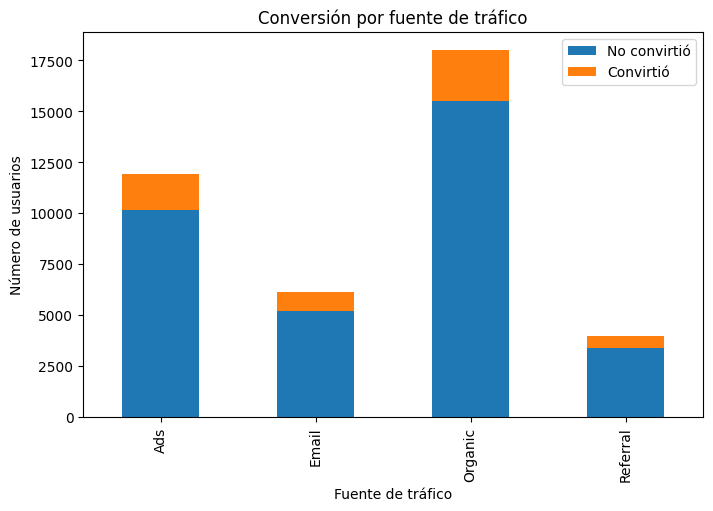

In [ ]:
# Por conteo

tabla_trafico.plot(kind='bar',stacked=True,figsize=(8,5))

plt.title('Conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Número de usuarios')
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

El gráfico muestra el número absoluto de usuarios que convirtieron y no convirtieron para cada fuente de tráfico. Se observa que Organic concentra el mayor volumen de usuarios y, en consecuencia, también el mayor número absoluto de conversiones. Sin embargo, el volumen por sí solo no permite comparar la efectividad de cada canal, ya que cada uno aporta una cantidad diferente de usuarios.

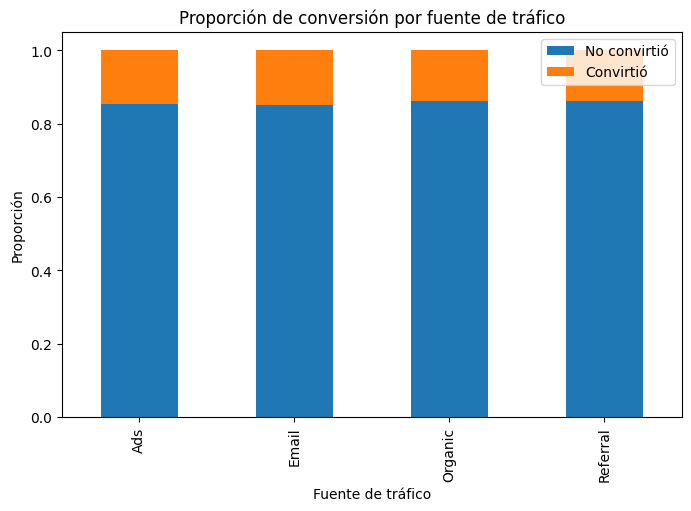

In [ ]:
# Normalizando

tabla_trafico_prop = pd.crosstab(df['traffic_source'],df['converted'],normalize='index')

tabla_trafico_prop.plot(kind='bar',stacked=True,figsize=(8,5))

plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

El gráfico presenta la proporción de usuarios que convirtieron y no convirtieron en cada fuente de tráfico. Se aprecia que Email presenta la mayor proporción de conversiones, seguido de Ads por ligera diferencia, mientras que Referral y Organic muestran porcentajes ligeramente menores a estos dos anteriores. Estas diferencias respaldan los resultados de la prueba Chi-cuadrado, que encontró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

### Relación entre el tipo de usuario y la conversión

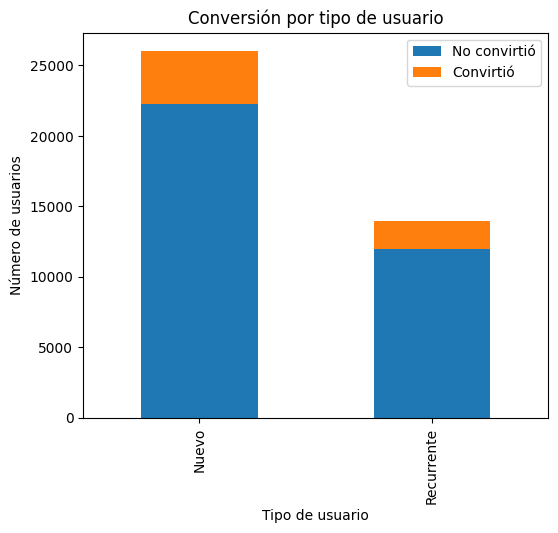

In [ ]:
tabla_usuario.plot(kind='bar',stacked=True,figsize=(6,5))

plt.title('Conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Número de usuarios')
plt.legend(['No convirtió', 'Convirtió'])
plt.show()


El gráfico muestra el número absoluto de usuarios que convirtieron y no convirtieron según su tipo. Se observa que los usuarios nuevos presentan un mayor número de conversiones; sin embargo, esto se explica principalmente porque representan una mayor proporción de la muestra total.

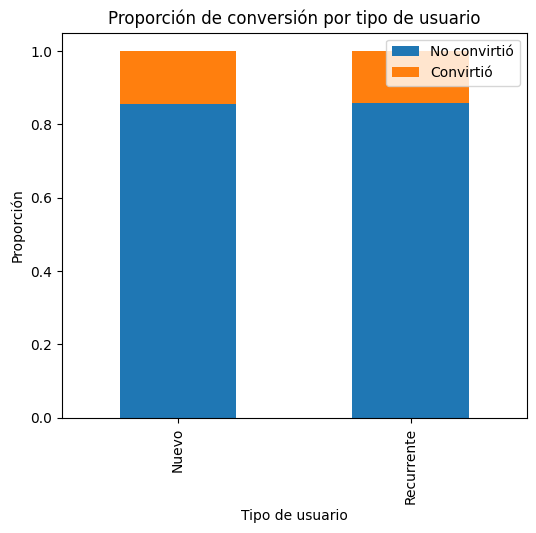

In [ ]:
tabla_usuario_prop = pd.crosstab(df['user_type'],df['converted'],normalize='index')

tabla_usuario_prop.plot(kind='bar',stacked=True,figsize=(6,5))

plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

Al analizar las proporciones, se observa que los usuarios nuevos y recurrentes presentan tasas de conversión muy similares. Esto coincide con la prueba Chi-cuadrado, que no encontró evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La página B obtuvo un gasto promedio de 68.75 por usuario convertido, mientras que la página A alcanzó 61.09.
- La prueba t de Welch mostró que esta diferencia es estadísticamente significativa (p < 0.05), por lo que es poco probable que se deba al azar.
- **Interpretación:**
Los usuarios que realizan una compra gastan más cuando interactúan con la versión B de la página, lo que representa un mayor valor económico por cliente convertido.

<br>

**Tasa de conversión:**
- La página B obtuvo una tasa de conversión aproximada de 15.96%, superior a la de la página A (12.57%).
- La prueba de dos proporciones confirmó que esta diferencia es estadísticamente significativa (p < 0.05).
- **Interpretación:**
La versión B no solo consigue que más usuarios conviertan, sino que además estos generan un mayor gasto promedio, lo que la convierte en la alternativa con mejor desempeño general.

---

#### 📊 **Segmentación por fuente de tráfico**
- Se encontró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.0341). Aunque Organic aporta el mayor volumen de visitantes, Email presenta la tasa de conversión más alta (14.99%), seguido por Ads (14.74%).
- **Interpretación:**
 La efectividad de un canal no debe evaluarse únicamente por la cantidad de usuarios que atrae, sino también por su capacidad para convertirlos en clientes. En este experimento, Email mostró el mejor desempeño relativo, lo que sugiere una oportunidad para optimizar la inversión en este canal.

 ---

#### 📊 **Segmentación por tipo de usuario**
- No se encontró una asociación estadísticamente significativa entre el tipo de usuario y la conversión (p = 0.4736). Las tasas de conversión fueron muy similares entre usuarios nuevos (14.36%) y recurrentes (14.09%).
- **Interpretación:**
El tipo de usuario no parece influir en la probabilidad de conversión dentro de este experimento. Por ello, no existe evidencia que justifique estrategias diferenciadas de conversión para usuarios nuevos y recurrentes.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Implementar la versión B como página de inicio, ya que obtuvo una tasa de conversión significativamente mayor y un mayor gasto promedio por usuario convertido, lo que puede traducirse en un incremento tanto del número de clientes como de los ingresos generados.
-  Fortalecer los canales con mejor desempeño relativo, especialmente Email, y continuar monitoreando el rendimiento de los distintos canales de adquisición para optimizar la inversión en marketing. Dado que no se observaron diferencias significativas entre usuarios nuevos y recurrentes, no se considera prioritario segmentar las estrategias de conversión según este criterio.

---

#### **Conclusión general:**
El experimento A/B proporciona evidencia estadística suficiente para recomendar la implementación de la versión B de la página de inicio. Esta versión mejora simultáneamente la tasa de conversión y el gasto promedio por usuario convertido. Adicionalmente, la fuente de tráfico mostró una influencia significativa en la conversión, mientras que el tipo de usuario no presentó diferencias relevantes. En conjunto, los resultados sugieren que la optimización de la landing page y la asignación eficiente del presupuesto entre canales de adquisición representan las principales oportunidades para incrementar el desempeño comercial.

